# ACI and AdaFTRL Experiments

This notebook runs the three implemented methods only:

- ACI with IPCW
- ACI without IPCW
- AdaFTRL

The synthetic stream is a right-censored log-normal survival problem with a known censoring survival function. The quantile model is intentionally shifted upward, so the algorithms need to adapt the played lower quantile level downward to approach the target lower coverage.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from online_survival.experiments import (
    SimulationConfig,
    behavior_svg,
    format_markdown_table,
    run_one_experiment,
    run_repeated_experiments,
    summarize_one_run,
    summarize_repeats,
)


def show_markdown(markdown):
    try:
        from IPython.display import Markdown, display
        display(Markdown(markdown))
    except Exception:
        print(markdown)


def show_svg(svg):
    try:
        from IPython.display import SVG, display
        display(SVG(svg))
    except Exception:
        print(svg[:1000])

## Experiment Setup

The target miscoverage is `alpha = 0.10`, so the target lower coverage is `0.90`. The same censored stream is replayed to all three algorithms in each run.

In [10]:
config = SimulationConfig(
    n_rounds=2000,
    alpha=0.10,
    tau_max=0.50,
    eta=0.015,
    model_log_shift=0.30,
    censoring_rate=0.12,
)

config

SimulationConfig(n_rounds=2000, alpha=0.1, tau_max=0.5, eta=0.015, tau_min=1e-06, x_low=-1.0, x_high=1.0, true_intercept=1.0, true_slope=0.35, true_sigma=0.55, model_log_shift=0.3, model_sigma=0.55, censoring_rate=0.12)

## One Run Behavior

The figure shows rolling realized lower coverage and the played quantile level on one shared data stream.

| algorithm | realized_coverage | average_conditional_coverage | average_surrogate_error | final_tau | censoring_fraction |
| --- | --- | --- | --- | --- | --- |
| ACI with IPCW | 0.8965 | 0.8798 | 0.1022 | 0.0337 | 0.3165 |
| ACI without IPCW | 0.8815 | 0.8677 | 0.1025 | 0.0315 | 0.3165 |
| AdaFTRL | 0.8895 | 0.8705 | 0.1079 | 0.0348 | 0.3165 |

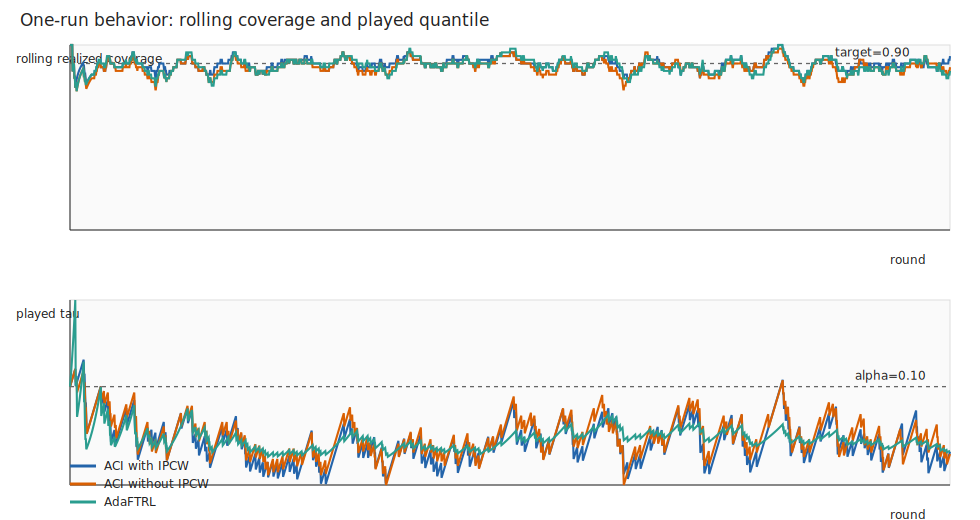

In [11]:
one_run = run_one_experiment(config, seed=7)

one_run_columns = [
    "algorithm",
    "realized_coverage",
    "average_conditional_coverage",
    "average_surrogate_error",
    "final_tau",
    "censoring_fraction",
]
show_markdown(format_markdown_table(summarize_one_run(one_run), one_run_columns, digits=4))
show_svg(behavior_svg(one_run, window=50))

## Repeated Experiments

The table repeats the same condition with different random seeds and reports means plus standard errors across runs.

In [7]:
repeated = run_repeated_experiments(config, n_repeats=100, seed=2026)
summary = summarize_repeats(repeated)

summary_columns = [
    "algorithm",
    "realized_coverage_mean",
    "realized_coverage_se",
    "average_conditional_coverage_mean",
    "average_conditional_coverage_se",
    "average_surrogate_error_mean",
    "final_tau_mean",
    "censoring_fraction_mean",
]
show_markdown(format_markdown_table(summary, summary_columns, digits=4))

| algorithm | realized_coverage_mean | realized_coverage_se | average_conditional_coverage_mean | average_conditional_coverage_se | average_surrogate_error_mean | final_tau_mean | censoring_fraction_mean |
| --- | --- | --- | --- | --- | --- | --- | --- |
| ACI with IPCW | 0.8971 | 0.0003 | 0.8972 | 0.0007 | 0.1032 | 0.0385 | 0.3040 |
| ACI without IPCW | 0.8828 | 0.0003 | 0.8825 | 0.0008 | 0.1023 | 0.0439 | 0.3040 |
| AdaFTRL | 0.8926 | 0.0003 | 0.8920 | 0.0007 | 0.1078 | 0.0367 | 0.3040 |